In [53]:
from osa_simple import YeniOSA
import matplotlib.pyplot as plt
import time
import pyvisa

In [45]:
IP = "192.168.54.1"
PORT = 5025

RESOURCE = f"TCPIP0::{IP}::{PORT}::SOCKET"

RESOURCE

'TCPIP0::192.168.54.1::5025::SOCKET'

In [46]:
osa = YeniOSA(RESOURCE)

osa

In [47]:
osa.connect()

print("Conectado")
print(osa.idn)

Conectado
EXFO,OSA20 FC/APC,YO161110143,2.0.6.0


Congigurar el barrido

In [48]:
CENTER = 1590
SPAN = 80
RESOLUTION = 0.2
# RESOLUTION = 0.05
SENSITIVITY = -65

osa.setup_sweep(
    center_nm=CENTER,
    span_nm=SPAN,
    resolution_nm=RESOLUTION,
    sensitivity_dbm=SENSITIVITY,
)

## Version 1

Deseamos llevar a cabo el procso de barrido paso a paso con esto podemos conocer cuanto tiempo tarda en capturar la traza y si es necesario hacer alguna modificacion al código de `osa_simple.py`

In [34]:
# ==========================================
# 1. Activar la traza
# ==========================================

osa.write(":TRACe1:ACT")
print("Traza activada")

# ==========================================
# 2. Configurar el tipo de traza
# ==========================================

osa.write(":TRACe1:TYPE 1")
print("Tipo configurado")

# ==========================================
# 3. Limpiar la memoria
# ==========================================

osa.write(":CLEar")
print("Memoria limpiada")

time.sleep(2)

VisaIOError: VI_ERROR_CONN_LOST (-1073807194): The connection for the given session has been lost.

In [8]:
# ==========================================
# 4. Iniciar el sweep
# ==========================================

osa.write(":INITiate:IMMediate")
print("Sweep iniciado")

Sweep iniciado


In [ ]:
respuesta = osa.query("*OPC?")

print(respuesta)

In [18]:
# Este codigo podria probarse para ver el progreso del sweep 

osa.write(":INITiate:IMMediate")

while True:
    progress = float(osa.query(":INITiate:PROGress?"))

    print(f"Progreso: {progress:.1f}%")

    if progress >= 100:
        break

    time.sleep(0.5)

Progreso: 0.0%
Progreso: 0.0%
Progreso: 0.0%
Progreso: 0.0%
Progreso: 0.0%
Progreso: 0.0%
Progreso: 0.0%
Progreso: 1.0%
Progreso: 3.0%
Progreso: 5.0%
Progreso: 7.0%
Progreso: 9.0%
Progreso: 10.0%
Progreso: 13.0%
Progreso: 14.0%
Progreso: 16.0%
Progreso: 18.0%
Progreso: 20.0%
Progreso: 22.0%
Progreso: 24.0%
Progreso: 26.0%
Progreso: 27.0%
Progreso: 29.0%
Progreso: 31.0%
Progreso: 33.0%
Progreso: 35.0%
Progreso: 37.0%
Progreso: 39.0%
Progreso: 41.0%
Progreso: 43.0%
Progreso: 44.0%
Progreso: 46.0%
Progreso: 48.0%
Progreso: 50.0%
Progreso: 52.0%
Progreso: 54.0%
Progreso: 56.0%
Progreso: 57.0%
Progreso: 60.0%
Progreso: 61.0%
Progreso: 63.0%
Progreso: 65.0%
Progreso: 67.0%
Progreso: 69.0%
Progreso: 71.0%
Progreso: 73.0%
Progreso: 75.0%
Progreso: 76.0%
Progreso: 79.0%
Progreso: 80.0%
Progreso: 82.0%
Progreso: 84.0%
Progreso: 86.0%
Progreso: 88.0%
Progreso: 90.0%
Progreso: 92.0%
Progreso: 94.0%
Progreso: 95.0%
Progreso: 97.0%
Progreso: 99.0%
Progreso: 100.0%


## Version 2

In [49]:
# Esto podria generar problemas porque no le da tiempo de pensar

osa.run_sweep(
    trace=1,
    averages=1,
    progress_poll_s=0.5,
    start_delay_s=2.0,
)

time.sleep(10)

trace = osa.get_trace(1)

Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress: 100.0%
Sweep completed.
Reading trace metadata...
Trace points reported by OSA: 40001
Reading trace power data...


In [54]:
osa.run_sweep(
    trace=1,
    averages=1,
    progress_poll_s=0.5,
    start_delay_s=2.0,
)

while True:

    try:
        start = osa.query(":TRACe1:DATA:STAR?")
        print("Metadata available.")
        break

    except pyvisa.errors.VisaIOError:
        print("Perate Perro.")
        time.sleep(0.2)

trace = osa.get_trace(1)

Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress: 100.0%
Sweep completed.
Perate Perro.
Metadata available.
Reading trace metadata...
Trace points reported by OSA: 40001
Reading trace power data...


In [50]:
start = osa.query(":TRACe1:DATA:STAR?")

In [51]:
start

'+1.55000000E-006'

In [41]:
trace = osa.get_trace(1)

Reading trace metadata...
Trace points reported by OSA: 40001
Reading trace power data...


## Continua codigo

In [8]:
dir(trace)

['__annotate_func__',
 '__annotations_cache__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'power_dbm',
 'save_txt',
 'wavelength_nm']

In [21]:
trace.wavelength_nm[:100]

array([1545.   , 1545.002, 1545.004, 1545.006, 1545.008, 1545.01 ,
       1545.012, 1545.014, 1545.016, 1545.018, 1545.02 , 1545.022,
       1545.024, 1545.026, 1545.028, 1545.03 , 1545.032, 1545.034,
       1545.036, 1545.038, 1545.04 , 1545.042, 1545.044, 1545.046,
       1545.048, 1545.05 , 1545.052, 1545.054, 1545.056, 1545.058,
       1545.06 , 1545.062, 1545.064, 1545.066, 1545.068, 1545.07 ,
       1545.072, 1545.074, 1545.076, 1545.078, 1545.08 , 1545.082,
       1545.084, 1545.086, 1545.088, 1545.09 , 1545.092, 1545.094,
       1545.096, 1545.098, 1545.1  , 1545.102, 1545.104, 1545.106,
       1545.108, 1545.11 , 1545.112, 1545.114, 1545.116, 1545.118,
       1545.12 , 1545.122, 1545.124, 1545.126, 1545.128, 1545.13 ,
       1545.132, 1545.134, 1545.136, 1545.138, 1545.14 , 1545.142,
       1545.144, 1545.146, 1545.148, 1545.15 , 1545.152, 1545.154,
       1545.156, 1545.158, 1545.16 , 1545.162, 1545.164, 1545.166,
       1545.168, 1545.17 , 1545.172, 1545.174, 1545.176, 1545.

In [22]:
trace.power_dbm[:100]

array([-100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100.])

In [10]:
trace

TraceData(wavelength_nm=array([1530.   , 1530.002, 1530.004, ..., 1609.996, 1609.998, 1610.   ],
      shape=(40001,)), power_dbm=array([-87.3120739, -85.153804 , -83.8240066, ..., -84.0339008,
       -83.020428 , -83.1325454], shape=(40001,)))

In [11]:
trace.save_txt("data/medicion_001.txt")

In [12]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"data/medicion_001_{timestamp}.txt"

trace.save_txt(filename)

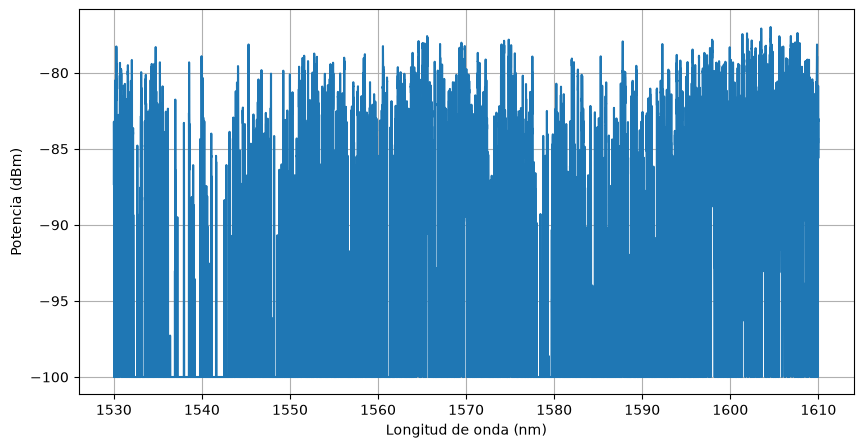

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    trace.wavelength_nm,
    trace.power_dbm
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Potencia (dBm)")
plt.grid(True)

In [43]:
osa.close()